In [ ]:
import torch

print("MPS available:", torch.backends.mps.is_available())
print("MPS built:", torch.backends.mps.is_built())

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

In [12]:
import os
import shutil
import random

source_dir = "datasetfvr/Originalimage"
train_dir = "dataset_split/train"
val_dir = "dataset_split/val"

split_ratio = 0.8

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

for class_name in os.listdir(source_dir):

    class_path = os.path.join(source_dir, class_name)

    # Skip files like .DS_Store
    if not os.path.isdir(class_path):
        continue

    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)

    images = os.listdir(class_path)
    random.shuffle(images)

    split = int(len(images) * split_ratio)

    for img in images[:split]:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(train_dir, class_name, img)
        )

    for img in images[split:]:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(val_dir, class_name, img)
        )

print("Train/Val split completed ✅")

Train/Val split completed ✅


In [14]:
from torch.utils.data import Dataset
from PIL import Image
import os

class FruitDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        for folder in os.listdir(root_dir):

            folder_path = os.path.join(root_dir, folder)
            if not os.path.isdir(folder_path):
                continue

            freshness = 1 if "Fresh" in folder else 0
            fruit = folder.replace("Fresh", "").replace("Rotten", "")

            for img_name in os.listdir(folder_path):
                self.samples.append(
                    (os.path.join(folder_path, img_name),
                     fruit,
                     freshness)
                )

        self.fruit_classes = sorted(list(set([s[1] for s in self.samples])))
        self.fruit_to_idx = {f:i for i,f in enumerate(self.fruit_classes)}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, fruit, freshness = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        fruit_label = self.fruit_to_idx[fruit]
        freshness_label = freshness

        return image, fruit_label, freshness_label

In [15]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

train_dataset = FruitDataset("dataset_split/train", transform)
val_dataset = FruitDataset("dataset_split/val", transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

print("Fruits:", train_dataset.fruit_classes)
print("Train images:", len(train_dataset))
print("Val images:", len(val_dataset))

Fruits: ['Apple', 'Banana', 'Grape', 'Guava', 'Jujube', 'Orange', 'Pomegranate', 'Strawberry']
Train images: 2560
Val images: 640


In [16]:
import torch
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

Device: mps


In [20]:
import torch.nn as nn
import torchvision.models as models

class MultiTaskMobileNet(nn.Module):
    def __init__(self, num_fruits):
        super().__init__()

        base = models.mobilenet_v3_large(pretrained=True)

        self.backbone = base.features
        self.pool = nn.AdaptiveAvgPool2d((1,1))

        # Correct feature size for MobileNetV3 Large
        in_features = 960

        self.fruit_head = nn.Linear(in_features, num_fruits)
        self.freshness_head = nn.Linear(in_features, 1)

    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)

        fruit = self.fruit_head(x)
        fresh = self.freshness_head(x)

        return fruit, fresh

In [27]:
model = MultiTaskMobileNet(len(train_dataset.fruit_classes)).to(device)

# Freeze backbone
for param in model.backbone.parameters():
    param.requires_grad = False

In [28]:
optimizer = torch.optim.Adam(
    list(model.fruit_head.parameters()) +
    list(model.freshness_head.parameters()),
    lr=1e-3
)

In [22]:
for images, fruit_labels, fresh_labels in train_loader:

    images = images.to(device)
    fruit_labels = fruit_labels.to(device)
    fresh_labels = fresh_labels.to(device)

    optimizer.zero_grad()

    fruit_out, fresh_out = model(images)

    loss_fruit = criterion_fruit(fruit_out, fruit_labels)
    loss_fresh = criterion_fresh(fresh_out.squeeze(), fresh_labels.float())

    loss = loss_fruit + 0.5 * loss_fresh

    loss.backward()
    optimizer.step()

    print("Batch loss:", loss.item())
    break

Batch loss: 2.405843496322632


In [29]:
from tqdm import tqdm

num_epochs = 5

for epoch in range(num_epochs):

    model.train()
    train_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for images, fruit_labels, fresh_labels in loop:

        images = images.to(device)
        fruit_labels = fruit_labels.to(device)
        fresh_labels = fresh_labels.to(device)

        optimizer.zero_grad()

        fruit_out, fresh_out = model(images)

        loss_fruit = criterion_fruit(fruit_out, fruit_labels)
        loss_fresh = criterion_fresh(fresh_out.squeeze(), fresh_labels.float())

        loss = loss_fruit + 0.5 * loss_fresh

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} Loss: {train_loss/len(train_loader):.4f}")

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, fruit_labels, _ in val_loader:

            images = images.to(device)
            fruit_labels = fruit_labels.to(device)

            fruit_out, _ = model(images)
            preds = fruit_out.argmax(1)

            correct += (preds == fruit_labels).sum().item()
            total += fruit_labels.size(0)

    print(f"Accuracy: {100*correct/total:.2f}%")

Epoch 1: 100%|██████████| 160/160 [00:53<00:00,  2.98it/s, loss=0.447]


Epoch 1 Loss: 0.9248
Accuracy: 90.78%


Epoch 2: 100%|██████████| 160/160 [00:53<00:00,  3.00it/s, loss=0.571]


Epoch 2 Loss: 0.4136
Accuracy: 94.06%


Epoch 3: 100%|██████████| 160/160 [00:52<00:00,  3.02it/s, loss=0.466]


Epoch 3 Loss: 0.3210
Accuracy: 96.88%


Epoch 4: 100%|██████████| 160/160 [00:53<00:00,  3.01it/s, loss=0.267]


Epoch 4 Loss: 0.2659
Accuracy: 97.34%


Epoch 5: 100%|██████████| 160/160 [00:53<00:00,  3.02it/s, loss=0.625]


Epoch 5 Loss: 0.2486
Accuracy: 98.44%


In [30]:
for param in model.backbone.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [32]:
from tqdm import tqdm

num_epochs = 5

for epoch in range(num_epochs):

    model.train()
    train_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for images, fruit_labels, fresh_labels in loop:

        images = images.to(device)
        fruit_labels = fruit_labels.to(device)
        fresh_labels = fresh_labels.to(device)

        optimizer.zero_grad()

        fruit_out, fresh_out = model(images)

        loss_fruit = criterion_fruit(fruit_out, fruit_labels)
        loss_fresh = criterion_fresh(fresh_out.squeeze(), fresh_labels.float())

        loss = loss_fruit + 0.5 * loss_fresh

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} Loss: {train_loss/len(train_loader):.4f}")

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, fruit_labels, _ in val_loader:

            images = images.to(device)
            fruit_labels = fruit_labels.to(device)

            fruit_out, _ = model(images)
            preds = fruit_out.argmax(1)

            correct += (preds == fruit_labels).sum().item()
            total += fruit_labels.size(0)

    print(f"Accuracy: {100*correct/total:.2f}%")

Epoch 1: 100%|██████████| 160/160 [01:05<00:00,  2.45it/s, loss=0.0582]


Epoch 1 Loss: 0.1479
Accuracy: 99.38%


Epoch 2: 100%|██████████| 160/160 [01:05<00:00,  2.45it/s, loss=0.0102] 


Epoch 2 Loss: 0.0666
Accuracy: 99.53%


Epoch 3: 100%|██████████| 160/160 [01:05<00:00,  2.44it/s, loss=0.00632]


Epoch 3 Loss: 0.0409
Accuracy: 99.53%


Epoch 4: 100%|██████████| 160/160 [01:06<00:00,  2.42it/s, loss=0.0267] 


Epoch 4 Loss: 0.0292
Accuracy: 98.59%


Epoch 5: 100%|██████████| 160/160 [01:05<00:00,  2.45it/s, loss=0.00633]


Epoch 5 Loss: 0.0334
Accuracy: 99.38%


In [33]:
import torch

torch.save({
    "model_state": model.state_dict(),
    "fruit_classes": train_dataset.fruit_classes
}, "multitask_fruit_model.pth")

print("Model saved as multitask_fruit_model.pth ✅")

Model saved as multitask_fruit_model.pth ✅


In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

fruit_preds = []
fruit_true = []

fresh_preds = []
fresh_true = []

with torch.no_grad():
    for images, fruit_labels, fresh_labels in val_loader:

        images = images.to(device)
        fruit_labels = fruit_labels.to(device)
        fresh_labels = fresh_labels.to(device)

        fruit_out, fresh_out = model(images)

        fruit_pred = fruit_out.argmax(1)
        fresh_pred = (torch.sigmoid(fresh_out.squeeze()) > 0.5).int()

        fruit_preds.extend(fruit_pred.cpu().numpy())
        fruit_true.extend(fruit_labels.cpu().numpy())

        fresh_preds.extend(fresh_pred.cpu().numpy())
        fresh_true.extend(fresh_labels.cpu().numpy())

print("🍎 Fruit Classification Report:")
print(classification_report(fruit_true, fruit_preds, target_names=train_dataset.fruit_classes))

print("🥦 Freshness Classification Report:")
print(classification_report(fresh_true, fresh_preds, target_names=["Rotten","Fresh"]))

🍎 Fruit Classification Report:
              precision    recall  f1-score   support

       Apple       0.98      1.00      0.99        80
      Banana       1.00      1.00      1.00        80
       Grape       1.00      1.00      1.00        80
       Guava       1.00      0.99      0.99        80
      Jujube       0.98      1.00      0.99        80
      Orange       1.00      0.99      0.99        80
 Pomegranate       1.00      0.97      0.99        80
  Strawberry       1.00      1.00      1.00        80

    accuracy                           0.99       640
   macro avg       0.99      0.99      0.99       640
weighted avg       0.99      0.99      0.99       640

🥦 Freshness Classification Report:
              precision    recall  f1-score   support

      Rotten       1.00      0.97      0.98       320
       Fresh       0.97      1.00      0.98       320

    accuracy                           0.98       640
   macro avg       0.98      0.98      0.98       640
weighted av

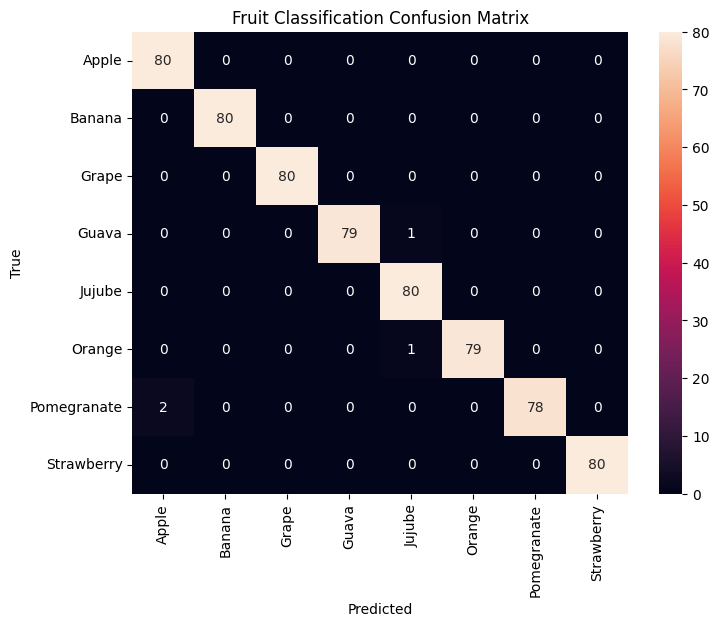

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(fruit_true, fruit_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=train_dataset.fruit_classes,
            yticklabels=train_dataset.fruit_classes)

plt.title("Fruit Classification Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

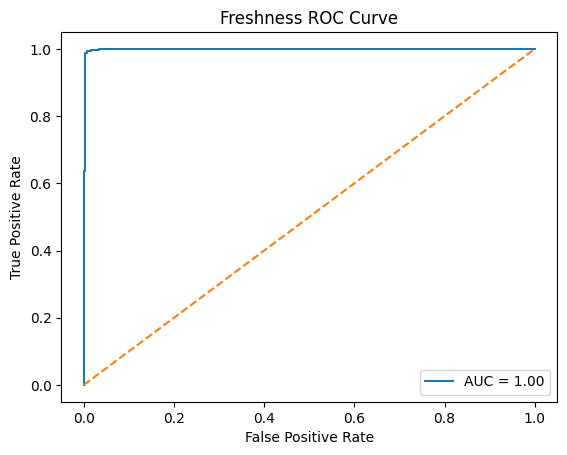

In [45]:
from sklearn.metrics import roc_curve, auc

fresh_probs = []

with torch.no_grad():
    for images, _, _ in val_loader:
        images = images.to(device)
        _, fresh_out = model(images)
        fresh_probs.extend(torch.sigmoid(fresh_out.squeeze()).cpu().numpy())

fpr, tpr, _ = roc_curve(fresh_true_all, fresh_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Freshness ROC Curve")
plt.legend()
plt.show()

In [46]:
import time

images, _, _ = next(iter(val_loader))
images = images.to(device)

start = time.time()
with torch.no_grad():
    model(images)
end = time.time()

print("Inference time per batch:", end-start)
print("Approx FPS:", len(images)/(end-start))

Inference time per batch: 0.008287906646728516
Approx FPS: 1930.523675277602


In [ ]:
import os
print("Model size (MB):", os.path.getsize("multitask_fruit_model.pth")/1e6)

Model size (MB): 12.128051


In [ ]:
import torch
dummy = torch.randn(1, 3, 224, 224).to(device)

torch.onnx.export(
    model,
    dummy,
    "multi_task_fruit.onnx",
    opset_version=11,
    input_names=["input"],
    output_names=["fruit","freshness"]
)
print("ONNX exported ✅")

/var/folders/z1/8gplv6w95fj5vl694z3vf2fr0000gn/T/ipykernel_10315/605138900.py:5: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


ONNX exported ✅
